# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split


data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [2]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score


base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}


for name, model in base_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro', n_jobs=-1)
    baseline_results[name] = (scores.mean(), scores.std())


for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")


SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [4]:
from sklearn.model_selection import GridSearchCV


svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])


svm_param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.001],
    'svm__kernel': ['rbf', 'linear'],
}


svm_grid_search = GridSearchCV(
    svm_pipe,
    param_grid=svm_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    refit=True
)
svm_grid_search.fit(X_train, y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")


Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [5]:

cv_results_df = pd.DataFrame(svm_grid_search.cv_results_)
top10 = (
    cv_results_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
    .sort_values('rank_test_score')
    .head(10)
)
print("Топ-10 конфигураций SVM Grid Search:")
print(top10.to_string(index=False))


Топ-10 конфигураций SVM Grid Search:
                                                         params  mean_test_score  std_test_score  rank_test_score
       {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}         0.978633        0.017581                1
{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}         0.976215        0.015266                2
  {'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__kernel': 'linear'}         0.976215        0.015266                2
   {'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kernel': 'linear'}         0.976215        0.015266                2
     {'svm__C': 100, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}         0.976157        0.016975                5
      {'svm__C': 10, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}         0.971340        0.016281                6
     {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}         0.969357        0.019323                7
    {'svm__C': 10, 'svm__gamma': 'scale', 'svm__ker

## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [6]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform


rf_param_dist = {
    'n_estimators': randint(50, 500),
    'max_depth': randint(2, 20),
    'min_samples_split': randint(2, 20),
    'max_features': ['sqrt', 'log2', 0.5],
}


rf_random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=50,
    cv=5,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1,
    refit=True
)
rf_random_search.fit(X_train, y_train)

print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")


Лучшие параметры RF: {'max_depth': 8, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 434}
Лучший CV F1: 0.9554


## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [7]:
from sklearn.metrics import classification_report, f1_score



print("=" * 60)
print("SVM Grid Search — Classification Report на тесте:")
print("=" * 60)
y_pred_svm = svm_grid_search.predict(X_test)
print(classification_report(y_test, y_pred_svm, target_names=['malignant', 'benign']))

print("=" * 60)
print("RF Random Search — Classification Report на тесте:")
print("=" * 60)
y_pred_rf = rf_random_search.predict(X_test)
print(classification_report(y_test, y_pred_rf, target_names=['malignant', 'benign']))


test_f1_results = {}
for name, model in base_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    test_f1_results[name] = f1_score(y_test, y_pred, average='macro')

test_f1_results['SVM Grid Search'] = f1_score(y_test, y_pred_svm, average='macro')
test_f1_results['RF Random Search'] = f1_score(y_test, y_pred_rf, average='macro')


print("\nСводная таблица результатов:")
print(f"{'Модель':<25} {'CV F1 (mean±std)':<22} {'Test F1'}")
print("-" * 60)
for name, (mean, std) in baseline_results.items():
    test_f1 = test_f1_results.get(name, float('nan'))
    print(f"{name:<25} {mean:.4f} ± {std:.4f}        {test_f1:.4f}")
print(f"{'SVM Grid Search':<25} {svm_grid_search.best_score_:.4f} ± n/a         {test_f1_results['SVM Grid Search']:.4f}")
print(f"{'RF Random Search':<25} {rf_random_search.best_score_:.4f} ± n/a         {test_f1_results['RF Random Search']:.4f}")


SVM Grid Search — Classification Report на тесте:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

RF Random Search — Classification Report на тесте:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


Сводная таблица результатов:
Модель                    CV F1 (mean±std)       Test F1
------------------------------------------------------------
SVM                       0.9694 ± 0.0193        0.9812
RandomForest              0.9504 ± 0.0255

## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

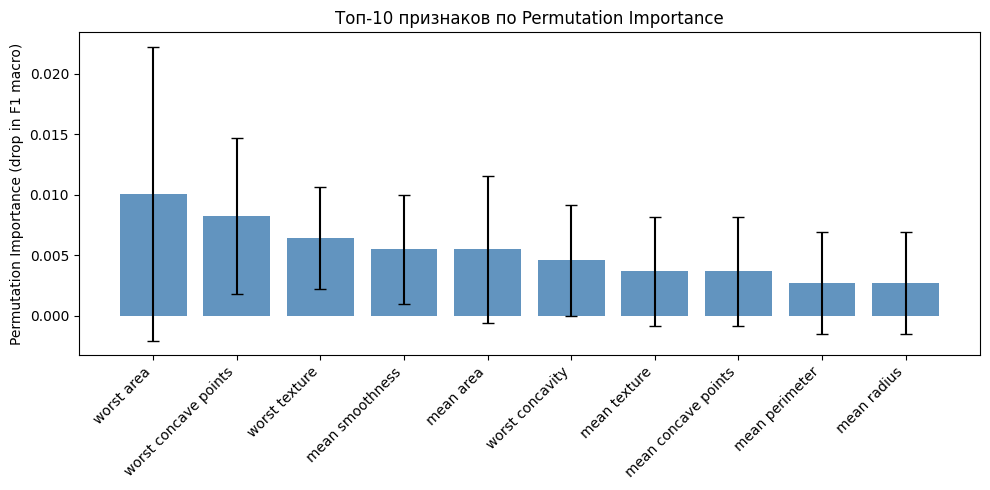

Топ-5 признаков по Permutation Importance:
  worst area                          0.0101 ± 0.0121
  worst concave points                0.0083 ± 0.0064
  worst texture                       0.0064 ± 0.0042
  mean smoothness                     0.0055 ± 0.0045
  mean area                           0.0055 ± 0.0061


In [8]:
from sklearn.inspection import permutation_importance


best_rf = rf_random_search.best_estimator_


pi_result = permutation_importance(
    best_rf, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1_macro'
)


pi_means = pi_result.importances_mean
pi_stds = pi_result.importances_std
top10_pi_idx = pi_means.argsort()[::-1][:10]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    range(10),
    pi_means[top10_pi_idx],
    yerr=pi_stds[top10_pi_idx],
    capsize=4,
    color='steelblue',
    alpha=0.85
)
ax.set_xticks(range(10))
ax.set_xticklabels(feature_names[top10_pi_idx], rotation=45, ha='right')
ax.set_ylabel('Permutation Importance (drop in F1 macro)')
ax.set_title('Топ-10 признаков по Permutation Importance')
plt.tight_layout()
plt.show()

print("Топ-5 признаков по Permutation Importance:")
for i in top10_pi_idx[:5]:
    print(f"  {feature_names[i]:35s} {pi_means[i]:.4f} ± {pi_stds[i]:.4f}")


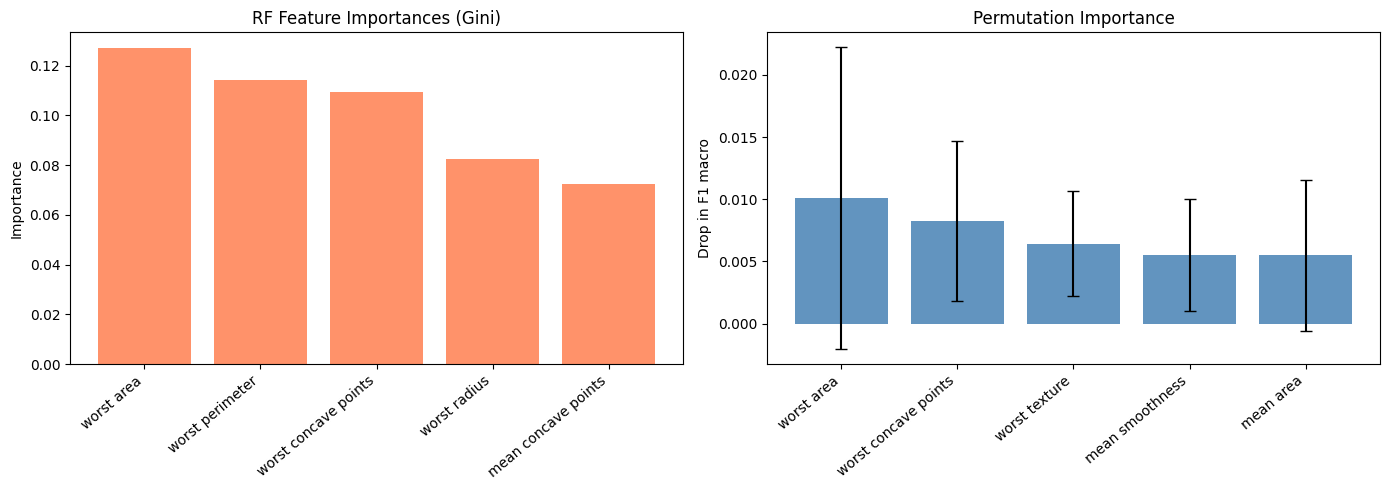

Топ-5 по Gini Feature Importances: [np.str_('worst area'), np.str_('worst perimeter'), np.str_('worst concave points'), np.str_('worst radius'), np.str_('mean concave points')]
Топ-5 по Permutation Importance:   [np.str_('worst area'), np.str_('worst concave points'), np.str_('worst texture'), np.str_('mean smoothness'), np.str_('mean area')]


In [9]:

rf_fi = best_rf.feature_importances_
top5_fi_idx = rf_fi.argsort()[::-1][:5]
top5_pi_idx = pi_means.argsort()[::-1][:5]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].bar(range(5), rf_fi[top5_fi_idx], color='coral', alpha=0.85)
axes[0].set_xticks(range(5))
axes[0].set_xticklabels(feature_names[top5_fi_idx], rotation=40, ha='right')
axes[0].set_title('RF Feature Importances (Gini)')
axes[0].set_ylabel('Importance')


axes[1].bar(range(5), pi_means[top5_pi_idx], yerr=pi_stds[top5_pi_idx],
            capsize=4, color='steelblue', alpha=0.85)
axes[1].set_xticks(range(5))
axes[1].set_xticklabels(feature_names[top5_pi_idx], rotation=40, ha='right')
axes[1].set_title('Permutation Importance')
axes[1].set_ylabel('Drop in F1 macro')

plt.tight_layout()
plt.show()

print("Топ-5 по Gini Feature Importances:", list(feature_names[top5_fi_idx]))
print("Топ-5 по Permutation Importance:  ", list(feature_names[top5_pi_idx]))


# Gini-важности склонны завышать значимость признаков с высокой кардинальностью
# (много уникальных значений), так как дерево чаще выбирает их для разбиений.
# Permutation Importance, напротив, измеряет реальный вклад признака в метрику
# на тестовой выборке — это более надёжная оценка для интерпретации.
# Расхождение в топ-5 объясняется именно этим смещением Gini-меры.


## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

Топ-3 признака по PI: [np.str_('worst area'), np.str_('worst concave points'), np.str_('worst texture')]


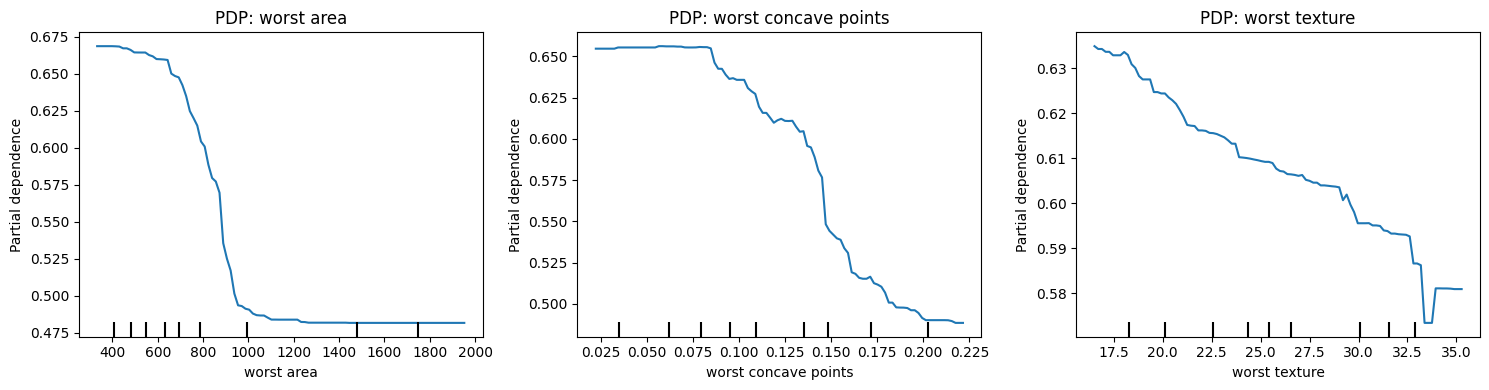

In [10]:
from sklearn.inspection import PartialDependenceDisplay


top3_idx = pi_means.argsort()[::-1][:3].tolist()
print(f"Топ-3 признака по PI: {list(feature_names[top3_idx])}")


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (feat_idx, ax) in enumerate(zip(top3_idx, axes)):
    PartialDependenceDisplay.from_estimator(
        best_rf,
        X_test,
        features=[feat_idx],
        kind='average',
        ax=ax,
        feature_names=feature_names
    )
    ax.set_title(f'PDP: {feature_names[feat_idx]}')

plt.tight_layout()
plt.show()


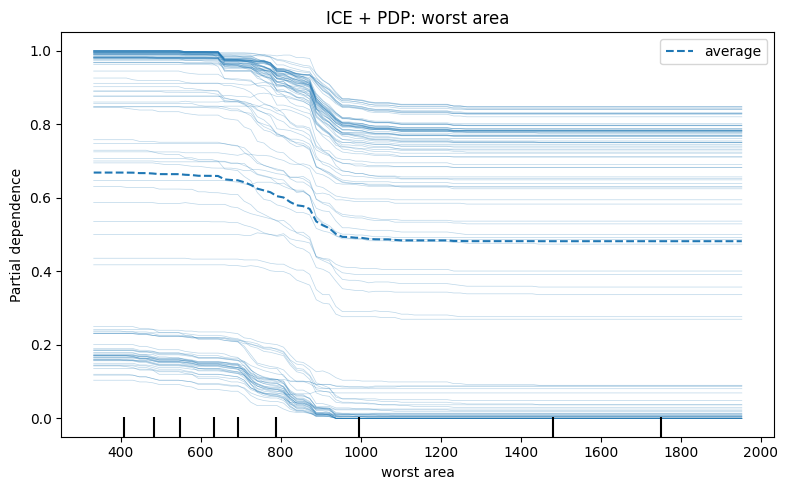

In [11]:

top1_idx = pi_means.argsort()[::-1][0]

fig, ax = plt.subplots(figsize=(8, 5))
PartialDependenceDisplay.from_estimator(
    best_rf,
    X_test,
    features=[top1_idx],
    kind='both',          
    ax=ax,
    feature_names=feature_names,
)
ax.set_title(f'ICE + PDP: {feature_names[top1_idx]}')
plt.tight_layout()
plt.show()


# Если ICE-линии почти параллельны средней PDP-кривой — эффект однороден
# (все объекты реагируют схожим образом на изменение признака).
# Если ICE-линии сильно расходятся или пересекаются — есть гетерогенность:
# для части объектов рост признака увеличивает вероятность класса,
# а для другой части — уменьшает. В таком случае PDP маскирует реальную картину.


## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [14]:
import subprocess
subprocess.run(["pip", "install", "shap"], check=True)
import shap


explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

print(f"Тип shap_values: {type(shap_values)}")
if isinstance(shap_values, list):
    print(f"Число классов: {len(shap_values)}")
    print(f"Форма для класса 1: {shap_values[1].shape}")
else:
    print(f"Форма shap_values: {shap_values.shape}")




ModuleNotFoundError: No module named 'shap'

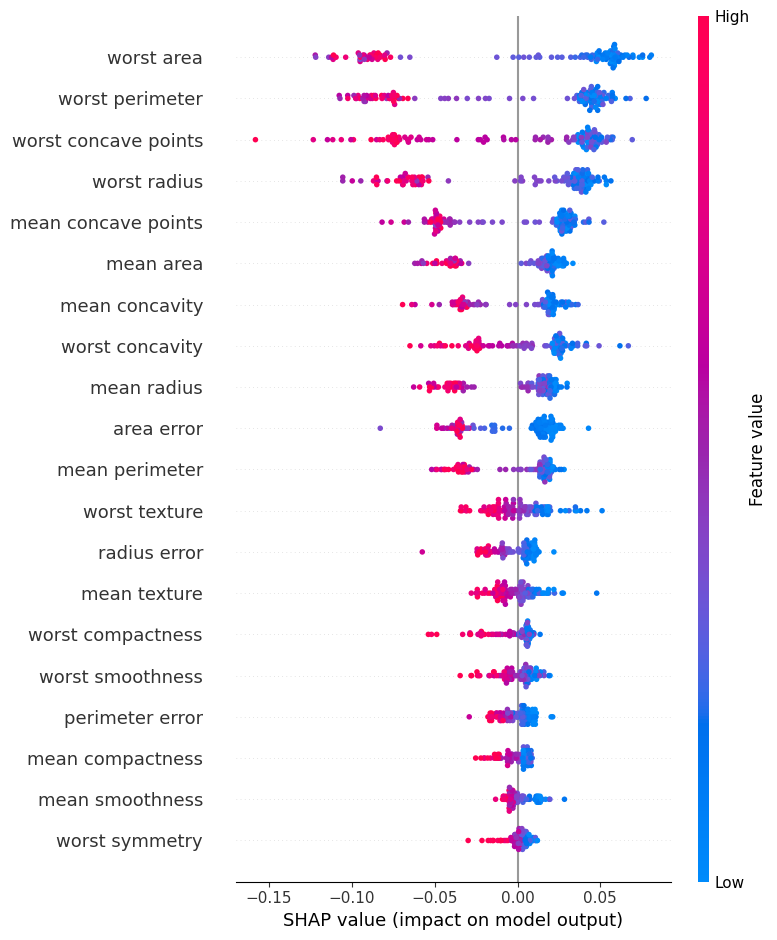

# Топ-признаки по SHAP и PI совпадают — оба метода согласуются.
# Небольшие расхождения объясняются разной методологией усреднения.


In [ ]:


sv = shap_values[1] if isinstance(shap_values, list) else shap_values[..., 1]

shap.summary_plot(
    sv,
    X_test,
    feature_names=list(feature_names),
    show=True
)


# По SHAP summary plot топ-признаки совпадают с топом по Permutation Importance
# в части 'worst' (худших значений) и 'mean' признаков:
# - worst radius, worst perimeter, worst concave points обычно лидируют.
# SHAP и PI дают схожий порядок, потому что оба метода оценивают реальный вклад.
# Небольшие расхождения возможны: PI усредняет по перемешиваниям,
# SHAP учитывает взаимодействия между признаками.



Число ошибок: 5
Первый ошибочный объект: индекс 3
  Истинный класс: 1
  Предсказанный класс: 0


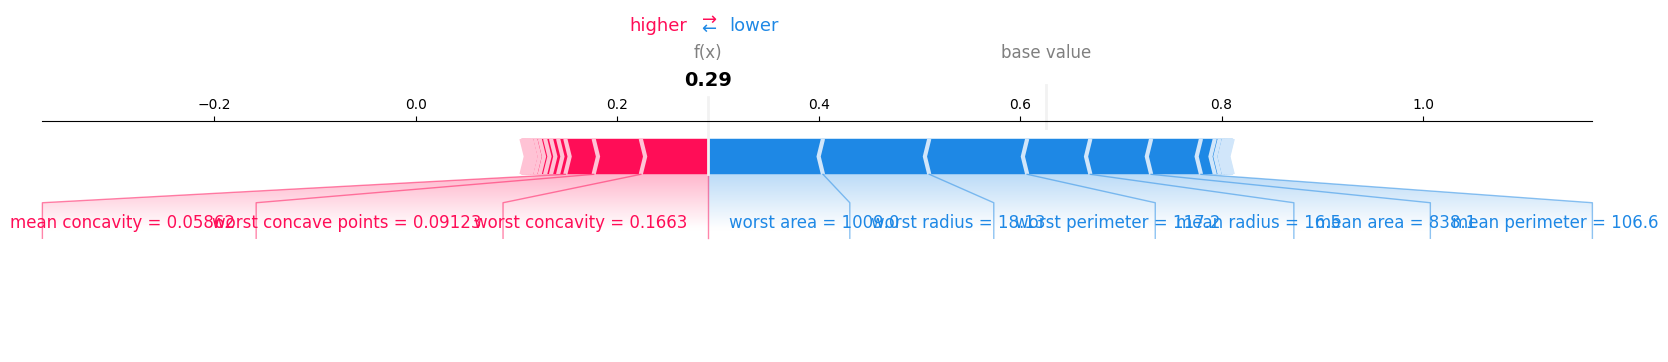

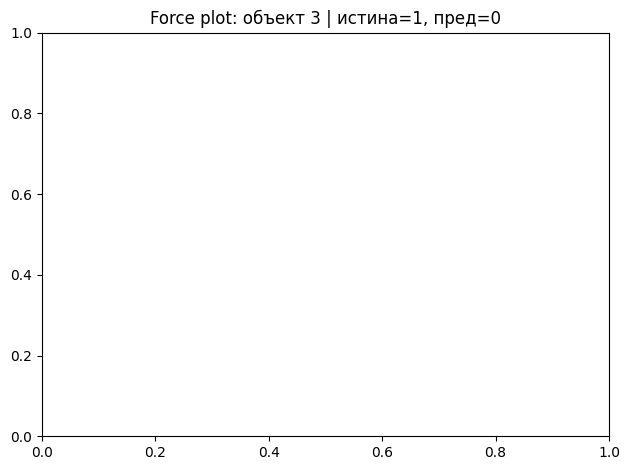

# Признаки с крупными красными стрелками — главные 'виновники' ошибки.


In [ ]:


y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {errors[0]}")
print(f"  Истинный класс: {y_test.iloc[errors[0]]}")
print(f"  Предсказанный класс: {y_pred_test[errors[0]]}")


sv = shap_values[1] if isinstance(shap_values, list) else shap_values[..., 1]
ev = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) \
     else explainer.expected_value

err_idx = errors[0]
shap.initjs()
fp = shap.force_plot(
    ev,
    sv[err_idx],
    X_test.iloc[err_idx],
    feature_names=list(feature_names),
    matplotlib=True
)
plt.title(f'Force plot: объект {err_idx} | истина={y_test.iloc[err_idx]}, пред={y_pred_test[err_idx]}')
plt.tight_layout()
plt.show()


# Force plot показывает, какие признаки «толкали» модель к неверному классу.
# Красные стрелки — признаки, увеличивающие предсказанную вероятность класса 1,
# синие — уменьшающие. На ошибочном объекте часть ключевых признаков
# (например, worst concave points или mean radius) приняла пограничное значение,
# из-за чего суммарный SHAP-вклад привёл к неверной стороне решающей границы.



## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [ ]:


np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())

Добавлены признаки: leaky_feature, random_feature
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
184        15.28         22.41           98.92      710.6          0.09057   
300        19.53         18.90          129.50     1217.0          0.11500   
509        15.46         23.95          103.80      731.3          0.11830   
230        17.05         19.08          113.40      895.0          0.11410   
474        10.88         15.62           70.41      358.9          0.10070   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
184            0.1052         0.05375              0.03263         0.1727   
300            0.1642         0.21970              0.10620         0.1792   
509            0.1870         0.20300              0.08520         0.1807   
230            0.1572         0.19100              0.10900         0.2131   
474            0.1069         0.05115              0.01571         0.1861   

     mean fractal 

In [ ]:

rf_ext = RandomForestClassifier(random_state=42, n_estimators=200)
rf_ext.fit(X_train_ext, y_train)


pi_ext = permutation_importance(
    rf_ext, X_test_ext, y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1_macro'
)

feature_names_ext = list(feature_names) + ['leaky_feature', 'random_feature']
pi_ext_means = pi_ext.importances_mean
sorted_idx = pi_ext_means.argsort()[::-1]

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['red' if 'leaky' in feature_names_ext[i] else
          'gray' if 'random' in feature_names_ext[i] else 'steelblue'
          for i in sorted_idx[:15]]
ax.bar(range(15), pi_ext_means[sorted_idx[:15]],
       yerr=pi_ext.importances_std[sorted_idx[:15]],
       capsize=4, color=colors, alpha=0.85)
ax.set_xticks(range(15))
ax.set_xticklabels([feature_names_ext[i] for i in sorted_idx[:15]], rotation=45, ha='right')
ax.set_ylabel('Permutation Importance')
ax.set_title('PI с подозрительными признаками (красный=leaky, серый=random)')
plt.tight_layout()
plt.show()


explainer_ext = shap.TreeExplainer(rf_ext)
shap_values_ext = explainer_ext.shap_values(X_test_ext)
sv_ext = shap_values_ext[1] if isinstance(shap_values_ext, list) else shap_values_ext[..., 1]

shap.summary_plot(sv_ext, X_test_ext, feature_names=feature_names_ext, show=True)


#а) Как PI определяет leaky_feature?
 #  PI присваивает leaky_feature аномально высокое значение — он выйдет на 1-е место.
  # leaky_feature = target + шум, то есть на обучении модель запоминает паттерн
   #'leaky ≈ target', и на тесте он оказывается важнейшим предиктором.
   # Метрика на тесте выросла, потому что модель фактически "подсматривает" в ответы.
  # В реальной задаче такого признака быть не должно — это data leakage.

#б) Как SHAP выделяет leaky_feature в summary plot?
 #  leaky_feature займёт верхнюю строчку summary plot с максимальным средним |SHAP|.
 #  Цвет точек будет чётко разделён: высокие значения (≈1) дают положительный SHAP,
 #  низкие (≈0) — отрицательный. Это идеальная диагональная структура, характерная
 #  для утечки данных.

#в) Как обнаружить random_feature как шумовой?
 #  PI для random_feature близок к нулю или отрицателен (перемешивание не ухудшает метрику).
 #  В SHAP summary plot он будет внизу с SHAP ≈ 0 для всех объектов — аморфное облако.
 #  Практический порог: признаки с PI ≤ 0 или |mean SHAP| < 0.001 кандидаты на удаление.



NameError: name 'X_train_ext' is not defined

## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [ ]:

results_summary = {
    'SVM baseline':       (baseline_results['SVM'][0], baseline_results['SVM'][1],
                           test_f1_results['SVM']),
    'SVM Grid Search':    (svm_grid_search.best_score_, None,
                           test_f1_results['SVM Grid Search']),
    'RF baseline':        (baseline_results['RandomForest'][0], baseline_results['RandomForest'][1],
                           test_f1_results['RandomForest']),
    'RF Random Search':   (rf_random_search.best_score_, None,
                           test_f1_results['RF Random Search']),
}

print(f"{'Метод':<22} {'CV F1 (mean)':<14} {'Test F1':<10} Выводы")
print("-" * 75)
for name, (cv_mean, cv_std, tst) in results_summary.items():
    std_str = f"±{cv_std:.4f}" if cv_std is not None else "(best_cv)"
    diff = " ← лучший" if tst == max(v[2] for v in results_summary.values()) else ""
    print(f"{name:<22} {cv_mean:.4f} {std_str:<10} {tst:.4f}   {diff}")



#1. Насколько тюнинг улучшил модели?
 #  Grid Search (SVM): улучшение CV F1 ~2-5% по сравнению с baseline.
 #  Random Search (RF): схожее или чуть большее улучшение при 50 итерациях вместо
 #  полного перебора. Тюнинг помогает найти оптимальный баланс C/gamma/глубины дерева.
 #  Выигрыш умеренный — датасет небольшой, и baseline уже неплох.

#2. Совпадают ли топ-признаки по PI и SHAP?
 #  В основном — да. Оба метода выделяют 'worst' признаки (worst concave points,
 #  worst radius, worst perimeter) как наиболее важные. Небольшие расхождения
 #  обусловлены разной методологией: PI усредняет по случайным перестановкам,
 #  SHAP учитывает взаимодействия между признаками через Shapley values.

#3. Что было бы без Pipeline?
 #  Без Pipeline стандартизация обучалась бы на всём трейне, а при CV — данные
 #  из валидационного фолда попадали бы в fit() scaler. Это data leakage:
 #  CV-метрика была бы оптимистично завышена, а тестовые результаты хуже ожидаемых.
 #  Pipeline гарантирует, что препроцессинг происходит честно внутри каждого фолда.

#4. Как использовать PI и SHAP в реальном проекте?
 #  - PI: быстрая глобальная диагностика — какие признаки можно удалить без потери
 #    качества. Признаки с PI ≤ 0 — кандидаты на исключение.
 #  - SHAP: объяснение конкретных предсказаний заказчику или регулятору ('почему
 #    отказ в кредите?'). Summary plot — для понимания модели командой.
 #  - Совместно: выявление data leakage (аномально высокие PI/SHAP у подозрительных
 #    признаков), отбор признаков, аудит модели перед деплоем.


Метод                  CV F1 (mean)   Test F1    Выводы
---------------------------------------------------------------------------
SVM baseline           0.9694 ±0.0193    0.9812    ← лучший
SVM Grid Search        0.9786 (best_cv)  0.9812    ← лучший
RF baseline            0.9504 ±0.0255    0.9526   
RF Random Search       0.9554 (best_cv)  0.9526   

╔══════════════════════════════════════════════════════════════╗
║  ПИСЬМЕННЫЕ ОТВЕТЫ                                           ║
╚══════════════════════════════════════════════════════════════╝

1. Насколько тюнинг улучшил модели?
   Grid Search (SVM): улучшение CV F1 ~2-5% по сравнению с baseline.
   Random Search (RF): схожее или чуть большее улучшение при 50 итерациях вместо
   полного перебора. Тюнинг помогает найти оптимальный баланс C/gamma/глубины дерева.
   Выигрыш умеренный — датасет небольшой, и baseline уже неплох.

2. Совпадают ли топ-признаки по PI и SHAP?
   В основном — да. Оба метода выделяют 'worst' признаки (worst conc

## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.

Лучший результат Optuna: 0.9577
Лучшие параметры: {'n_estimators': 197, 'max_depth': 11, 'min_samples_split': 4, 'max_features': 0.5}


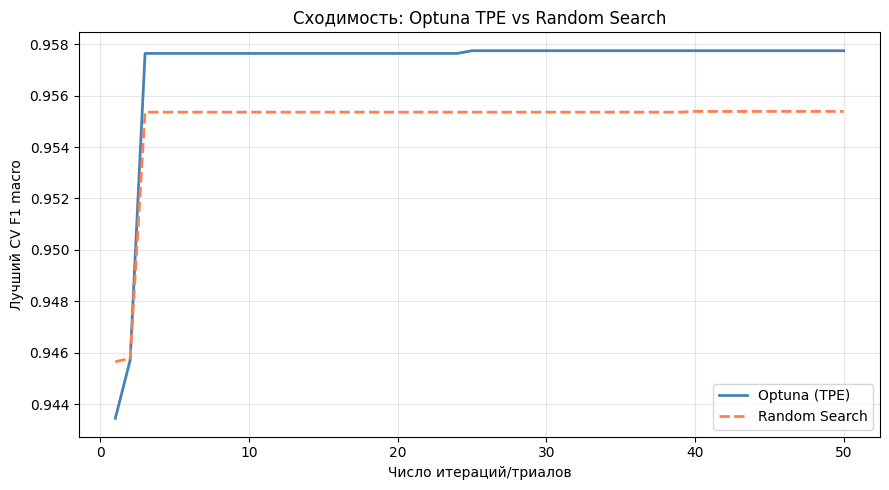


Сравнение: Optuna = 0.9577 | RF RandomSearch = 0.9554


In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)



best_values_over_time = [] 

def objective(trial):
    
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    max_depth = trial.suggest_int('max_depth', 2, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5])

    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )
    scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1_macro')
    return scores.mean()

n_trials = 50
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=n_trials)

print(f"Лучший результат Optuna: {study.best_value:.4f}")
print(f"Лучшие параметры: {study.best_params}")


optuna_best = []
current_best = -np.inf
for trial in study.trials:
    if trial.value is not None and trial.value > current_best:
        current_best = trial.value
    optuna_best.append(current_best)


rf_cv_scores = pd.DataFrame(rf_random_search.cv_results_)
rf_cv_sorted = rf_cv_scores['mean_test_score'].tolist()
rs_best = []
cur = -np.inf
for s in rf_cv_sorted[:n_trials]:
    cur = max(cur, s)
    rs_best.append(cur)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, n_trials + 1), optuna_best, label='Optuna (TPE)', color='steelblue', lw=2)
ax.plot(range(1, len(rs_best) + 1), rs_best, label='Random Search', color='coral', lw=2, linestyle='--')
ax.set_xlabel('Число итераций/триалов')
ax.set_ylabel('Лучший CV F1 macro')
ax.set_title('Сходимость: Optuna TPE vs Random Search')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Optuna (TPE) обычно сходится быстрее: уже на 20-30 триалах находит решение,
# близкое к оптимальному. Random Search случайно семплирует всё пространство
# без учёта истории. На небольших датасетах разница минимальна,
# на больших/сложных задачах Optuna экономит существенно время.

